# Phase 8 — Customer Segmentation and Revenue Risk

## Purpose

Segmentation divides customers into meaningful groups
based on their behaviour and value to the business.

This phase answers three questions:
1. Which customer segments have the highest churn risk?
2. Which segments represent the most revenue at risk?
3. Which segments should the business prioritise?

## Segmentation approach

We use a SaaS-adapted RFM framework:

Standard RFM (e-commerce):
- Recency   = how recently they purchased
- Frequency = how often they purchase
- Monetary  = how much they spend

SaaS-adapted (subscription):
- Tenure    = how long they have been a customer
- Engagement= how many features they use
- Monetary  = monthly charges (plan value)

These three dimensions create customer segments
that combine financial value with churn risk
to identify exactly where to focus retention effort.

## Why this matters

Not all churning customers cost equally.
A high-value customer churning is a crisis.
A low-value customer churning is a footnote.

This segmentation ensures retention resources
flow to where they create maximum business impact.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/cleaned/telco_churn_clean.csv')

print("Data loaded for segmentation")
print(f"Customers : {len(df):,}")
print()

# ── STEP 1: BUILD FEATURE ENGAGEMENT SCORE ───────────────
# Engagement = how many value-added services a customer uses
# More services = more embedded = harder to leave
# This is called product stickiness

# Each of these columns contains 'Yes', 'No', or
# 'No internet service' / 'No phone service'
# We convert to binary: Yes=1, anything else=0
# Then sum to get total services per customer

service_cols = [
    'PhoneService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

# For each service column create a binary version
# .apply() runs a function on every value in the column
# lambda is a small anonymous function
# x == 'Yes' returns True(1) or False(0) for each cell
for col in service_cols:
    df[f'{col}_bin'] = df[col].apply(
        lambda x: 1 if x == 'Yes' else 0
    )

# Sum all binary service columns to get engagement score
# This tells us how many services each customer uses
bin_cols = [f'{col}_bin' for col in service_cols]
df['engagement_score'] = df[bin_cols].sum(axis=1)

# axis=1 means sum across columns for each row
# axis=0 would mean sum down rows for each column

print("Engagement score distribution:")
print(df['engagement_score'].value_counts().sort_index())
print()
print(f"Average engagement score : "
      f"{df['engagement_score'].mean().round(2)}")
print(f"Churned customers avg    : "
      f"{df[df['Churn']==1]['engagement_score'].mean().round(2)}")
print(f"Retained customers avg   : "
      f"{df[df['Churn']==0]['engagement_score'].mean().round(2)}")

Data loaded for segmentation
Customers : 7,032

Engagement score distribution:
engagement_score
0      80
1    2247
2     996
3    1041
4    1060
5     825
6     524
7     259
Name: count, dtype: int64

Average engagement score : 2.94
Churned customers avg    : 2.68
Retained customers avg   : 3.04


In [2]:
# ── STEP 2: CREATE SEGMENTATION DIMENSIONS ───────────────
# We reduce each continuous variable to a simple
# High / Medium / Low category
# This makes segments interpretable to non-technical
# business stakeholders — a CEO understands
# "High Value, Low Engagement" immediately

# ── TENURE SEGMENT ───────────────────────────────────────
# Based on our cohort analysis findings:
# 0-12 months = New (highest risk)
# 13-36 months = Growing (moderate risk)
# 37-72 months = Mature (lowest risk)

def tenure_segment(tenure):
    if tenure <= 12:
        return 'New'
    elif tenure <= 36:
        return 'Growing'
    else:
        return 'Mature'

df['tenure_segment'] = df['tenure'].apply(tenure_segment)

# ── VALUE SEGMENT ─────────────────────────────────────────
# Based on monthly charges
# We use percentiles so segments are balanced in size
# 33rd percentile = bottom third of payers
# 66th percentile = middle third
# Above 66th = top third

p33 = df['MonthlyCharges'].quantile(0.33)
p66 = df['MonthlyCharges'].quantile(0.66)

print(f"Monthly charge percentiles:")
print(f"  33rd : ${p33:.2f}")
print(f"  66th : ${p66:.2f}")
print()

def value_segment(charge):
    if charge <= p33:
        return 'Low Value'
    elif charge <= p66:
        return 'Mid Value'
    else:
        return 'High Value'

df['value_segment'] = df['MonthlyCharges'].apply(value_segment)

# ── ENGAGEMENT SEGMENT ────────────────────────────────────
# Based on engagement score we calculated in Cell 1
# 0-2 services = Low engagement
# 3-4 services = Medium engagement
# 5-7 services = High engagement

def engagement_segment(score):
    if score <= 2:
        return 'Low Eng'
    elif score <= 4:
        return 'Mid Eng'
    else:
        return 'High Eng'

df['engagement_segment'] = df[
    'engagement_score'
].apply(engagement_segment)

# ── COMBINED RISK SEGMENT ────────────────────────────────
# Combine tenure and value into one risk label
# This is the primary segment used for prioritisation
# New + High Value = worst possible combination
# Mature + Low Value = least concerning combination

def risk_segment(row):
    tenure = row['tenure_segment']
    value  = row['value_segment']

    if tenure == 'New' and value == 'High Value':
        return '1_Critical'
    elif tenure == 'New' and value == 'Mid Value':
        return '2_High'
    elif tenure == 'New' and value == 'Low Value':
        return '3_High'
    elif tenure == 'Growing' and value == 'High Value':
        return '4_Medium'
    elif tenure == 'Growing':
        return '5_Medium'
    elif tenure == 'Mature' and value == 'High Value':
        return '6_Low'
    else:
        return '7_Low'

df['risk_segment'] = df.apply(risk_segment, axis=1)

print("Segment distributions:")
print()
print("Tenure segments:")
print(df['tenure_segment'].value_counts())
print()
print("Value segments:")
print(df['value_segment'].value_counts())
print()
print("Engagement segments:")
print(df['engagement_segment'].value_counts())

Monthly charge percentiles:
  33rd : $50.21
  66th : $83.25

Segment distributions:

Tenure segments:
tenure_segment
Mature     3001
New        2175
Growing    1856
Name: count, dtype: int64

Value segments:
value_segment
High Value    2388
Mid Value     2323
Low Value     2321
Name: count, dtype: int64

Engagement segments:
engagement_segment
Low Eng     3323
Mid Eng     2101
High Eng    1608
Name: count, dtype: int64


In [3]:
# ── STEP 3: ANALYSE CHURN AND REVENUE BY SEGMENT ─────────
print("=" * 65)
print("SEGMENT ANALYSIS — CHURN AND REVENUE RISK")
print("=" * 65)

# ── TENURE × VALUE CROSS ANALYSIS ────────────────────────
# This creates a 3×3 grid showing churn rate at every
# combination of tenure segment and value segment
# This is the core revenue risk intelligence table

segment_analysis = df.groupby(
    ['tenure_segment', 'value_segment'],
    observed=True
).agg(
    customers     = ('Churn', 'count'),
    churned       = ('Churn', 'sum'),
    avg_charge    = ('MonthlyCharges', 'mean'),
    avg_tenure    = ('tenure', 'mean')
).reset_index()

segment_analysis['churn_rate'] = round(
    segment_analysis['churned'] /
    segment_analysis['customers'] * 100, 1
)

segment_analysis['monthly_rev_at_risk'] = round(
    segment_analysis['churned'] *
    segment_analysis['avg_charge'], 0
)

segment_analysis['annual_rev_at_risk'] = round(
    segment_analysis['monthly_rev_at_risk'] * 12, 0
)

segment_analysis['avg_charge'] = segment_analysis[
    'avg_charge'
].round(2)

segment_analysis['avg_tenure'] = segment_analysis[
    'avg_tenure'
].round(1)

# Sort by annual revenue at risk — highest first
segment_analysis = segment_analysis.sort_values(
    'annual_rev_at_risk', ascending=False
)

print(segment_analysis[[
    'tenure_segment', 'value_segment',
    'customers', 'churned', 'churn_rate',
    'avg_charge', 'annual_rev_at_risk'
]].to_string(index=False))

print()
print(f"Total annual revenue at risk : "
      f"${segment_analysis['annual_rev_at_risk'].sum():,.0f}")

SEGMENT ANALYSIS — CHURN AND REVENUE RISK
tenure_segment value_segment  customers  churned  churn_rate  avg_charge  annual_rev_at_risk
           New     Mid Value        854      460        53.9       69.13            381612.0
           New    High Value        388      287        74.0       92.15            317352.0
       Growing    High Value        602      274        45.5       94.28            309984.0
        Mature    High Value       1398      257        18.4       99.68            307404.0
       Growing     Mid Value        650      150        23.1       68.04            122472.0
           New     Low Value        933      290        31.1       29.35            102132.0
        Mature     Mid Value        819       74         9.0       68.47             60804.0
       Growing     Low Value        604       50         8.3       27.16             16296.0
        Mature     Low Value        784       27         3.4       26.37              8544.0

Total annual revenue at ris

Segment analysis rebuilt successfully
Segments created : 9

Pivot tables created:

Churn rate pivot:
value_segment   Low Value  Mid Value  High Value
tenure_segment                                  
New                  31.1       53.9        74.0
Growing               8.3       23.1        45.5
Mature                3.4        9.0        18.4

Revenue at risk pivot ($):
value_segment   Low Value  Mid Value  High Value
tenure_segment                                  
New              102136.0   381607.0    317352.0
Growing           16297.0   122476.0    309986.0
Mature             8544.0    60803.0    307398.0



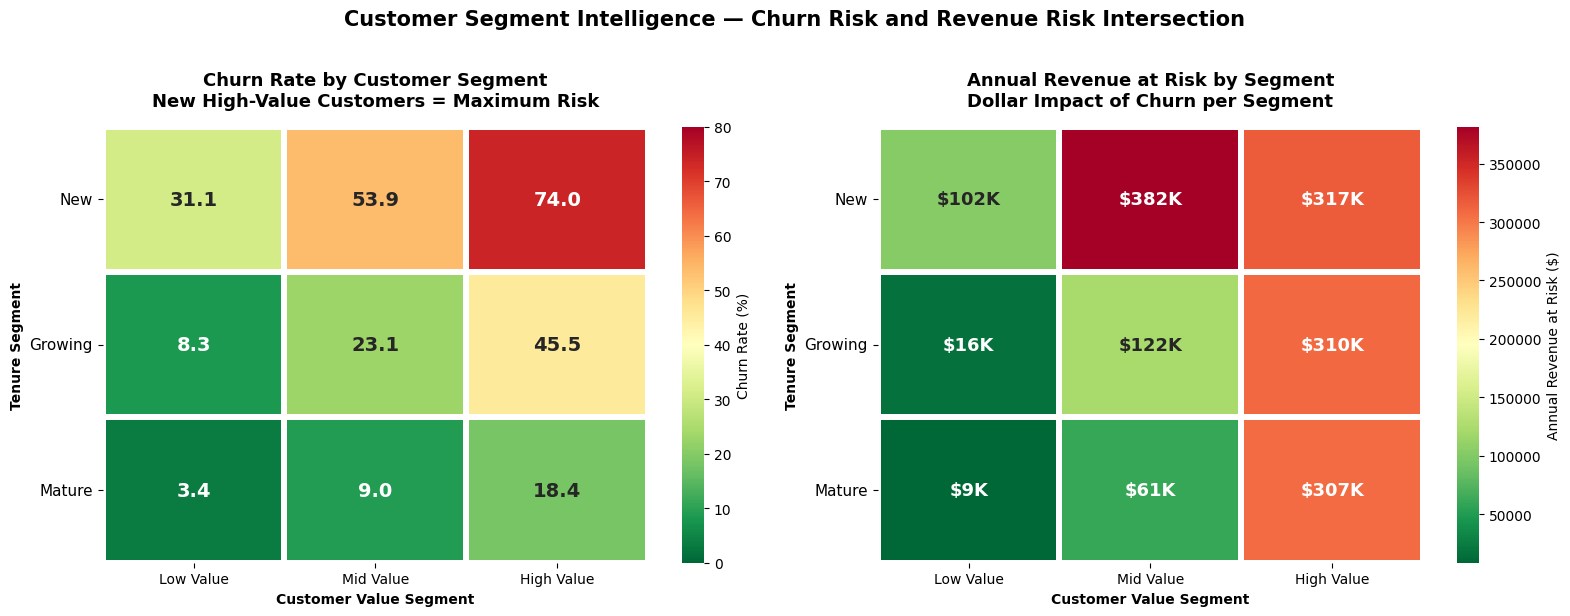

Segment risk heatmap saved successfully


In [4]:
# ── CELL 4: REVENUE RISK HEATMAP ─────────────────────────
# Rebuilding segment_analysis here as a safety measure
# so this cell works independently even if Cell 3
# lost its state between executions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reload data fresh
df = pd.read_csv('../data/cleaned/telco_churn_clean.csv')

# Rebuild percentile boundaries
p33 = df['MonthlyCharges'].quantile(0.33)
p66 = df['MonthlyCharges'].quantile(0.66)

# Rebuild segmentation functions
def tenure_segment(tenure):
    if tenure <= 12:
        return 'New'
    elif tenure <= 36:
        return 'Growing'
    else:
        return 'Mature'

def value_segment(charge):
    if charge <= p33:
        return 'Low Value'
    elif charge <= p66:
        return 'Mid Value'
    else:
        return 'High Value'

# Rebuild segments
df['tenure_segment'] = df['tenure'].apply(tenure_segment)
df['value_segment']  = df['MonthlyCharges'].apply(value_segment)

# Rebuild segment_analysis
segment_analysis = df.groupby(
    ['tenure_segment', 'value_segment'],
    observed=True
).agg(
    customers  = ('Churn', 'count'),
    churned    = ('Churn', 'sum'),
    avg_charge = ('MonthlyCharges', 'mean')
).reset_index()

segment_analysis['churn_rate'] = round(
    segment_analysis['churned'] /
    segment_analysis['customers'] * 100, 1
)

segment_analysis['annual_rev_at_risk'] = round(
    segment_analysis['churned'] *
    segment_analysis['avg_charge'] * 12, 0
)

segment_analysis['avg_charge'] = segment_analysis[
    'avg_charge'
].round(2)

print("Segment analysis rebuilt successfully")
print(f"Segments created : {len(segment_analysis)}")
print()

# ── DEFINE AXIS ORDERS ───────────────────────────────────
tenure_order = ['New', 'Growing', 'Mature']
value_order  = ['Low Value', 'Mid Value', 'High Value']

# ── CREATE PIVOT TABLES ───────────────────────────────────
# pivot_table() reshapes data from rows into a grid
# index = what becomes the row labels (y axis)
# columns = what becomes column labels (x axis)
# values = what fills each cell of the grid
# This creates a 3x3 matrix of churn rates

churn_pivot = segment_analysis.pivot_table(
    index='tenure_segment',
    columns='value_segment',
    values='churn_rate',
    observed=True
)

# Reindex forces our chosen display order
# Without this pandas sorts alphabetically
churn_pivot = churn_pivot.reindex(
    index=tenure_order,
    columns=value_order
)

revenue_pivot = segment_analysis.pivot_table(
    index='tenure_segment',
    columns='value_segment',
    values='annual_rev_at_risk',
    observed=True
)

revenue_pivot = revenue_pivot.reindex(
    index=tenure_order,
    columns=value_order
)

print("Pivot tables created:")
print()
print("Churn rate pivot:")
print(churn_pivot)
print()
print("Revenue at risk pivot ($):")
print(revenue_pivot)
print()

# ── BUILD THE HEATMAP FIGURE ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax1, ax2 = axes

# ── LEFT: CHURN RATE HEATMAP ─────────────────────────────
# RdYlGn_r = reversed Red-Yellow-Green
# High values = Red (bad = high churn)
# Low values = Green (good = low churn)
# vmin=0, vmax=80 sets colour scale boundaries
# annot=True shows the number inside each cell
# fmt='.1f' shows one decimal place

sns.heatmap(
    churn_pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    vmin=0,
    vmax=80,
    linewidths=3,
    linecolor='white',
    ax=ax1,
    cbar_kws={'label': 'Churn Rate (%)'},
    annot_kws={'size': 14, 'weight': 'bold'}
)

ax1.set_title(
    'Churn Rate by Customer Segment\n'
    'New High-Value Customers = Maximum Risk',
    fontweight='bold',
    fontsize=13,
    pad=15
)
ax1.set_xlabel('Customer Value Segment', fontweight='bold')
ax1.set_ylabel('Tenure Segment', fontweight='bold')
ax1.set_yticklabels(
    ax1.get_yticklabels(),
    rotation=0,
    fontsize=11
)

# ── RIGHT: REVENUE AT RISK HEATMAP ───────────────────────
# We format cell labels as dollar amounts in thousands
# applymap() applies a function to every cell
# lambda x: creates an inline function
# f'${x/1000:.0f}K' formats as $317K style
# pd.notna(x) checks the cell is not empty

# .map() replaced .applymap() in pandas 2.1+
# Both do the same thing — apply a function to every cell
revenue_annot = revenue_pivot.map(
    lambda x: f'${x/1000:.0f}K'
    if pd.notna(x) else 'N/A'
)

sns.heatmap(
    revenue_pivot,
    annot=revenue_annot,
    fmt='',
    cmap='RdYlGn_r',
    linewidths=3,
    linecolor='white',
    ax=ax2,
    cbar_kws={'label': 'Annual Revenue at Risk ($)'},
    annot_kws={'size': 13, 'weight': 'bold'}
)

ax2.set_title(
    'Annual Revenue at Risk by Segment\n'
    'Dollar Impact of Churn per Segment',
    fontweight='bold',
    fontsize=13,
    pad=15
)
ax2.set_xlabel('Customer Value Segment', fontweight='bold')
ax2.set_ylabel('Tenure Segment', fontweight='bold')
ax2.set_yticklabels(
    ax2.get_yticklabels(),
    rotation=0,
    fontsize=11
)

fig.suptitle(
    'Customer Segment Intelligence — '
    'Churn Risk and Revenue Risk Intersection',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    '../reports/figures/08_segment_risk_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Segment risk heatmap saved successfully")

Engagement score rebuilt successfully
Unique scores : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

ENGAGEMENT SCORE vs CHURN RATE

Services Used   Customers   Churn Rate   Avg Charge
----------------------------------------------------
0              80.0        43.8%       $24.90  ██████████████
1              2247.0      21.7%       $33.03  ███████
2              996.0       43.5%       $65.53  ██████████████
3              1041.0      34.7%       $73.16  ███████████
4              1060.0      27.3%       $82.62  █████████
5              825.0       22.1%       $89.51  ███████
6              524.0       12.6%       $95.44  ████
7              259.0       5.8%       $102.70  █

Churn rate at 0 services : 43.8%
Churn rate at 7 services : 5.8%
Total reduction          : 38.0 percentage points

Product stickiness hypothesis:
CONFIRMED — more services = lower churn


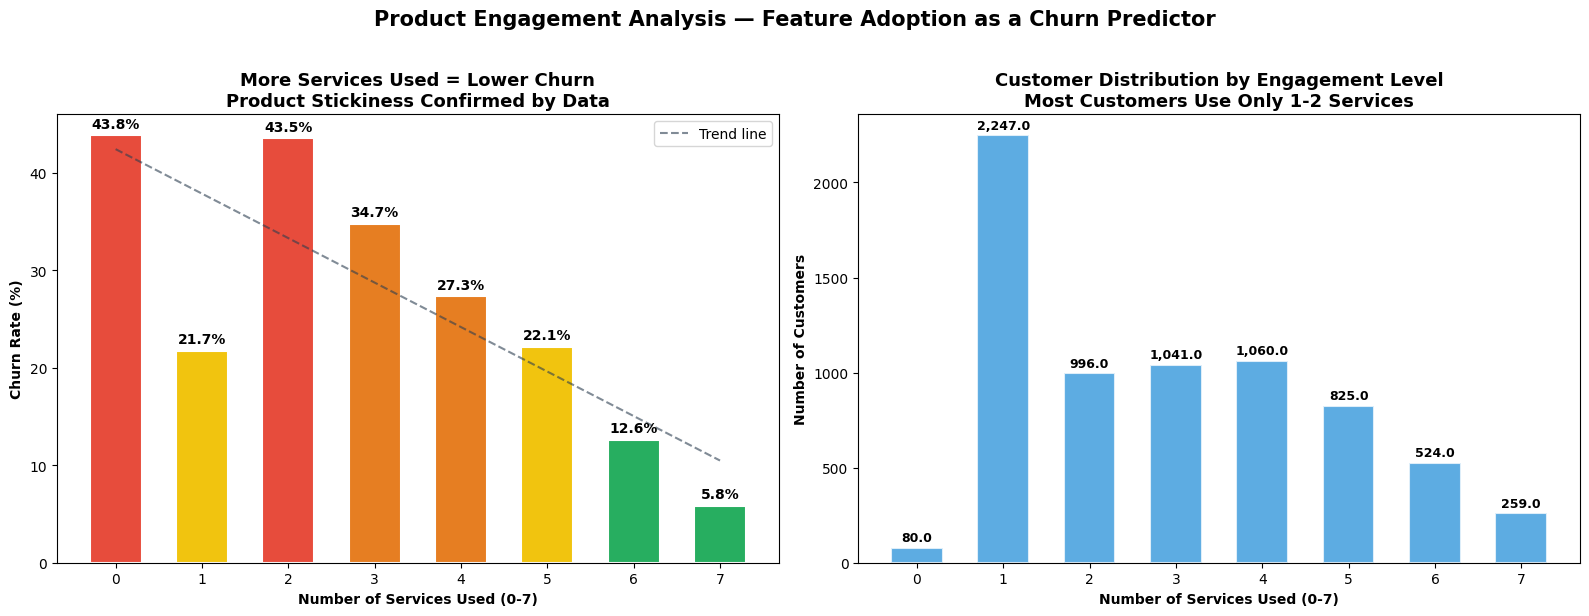

Engagement chart saved successfully


In [5]:
# ── CELL 5: ENGAGEMENT IMPACT ANALYSIS ───────────────────
# Self-contained cell — rebuilds everything it needs
# so it works regardless of kernel state

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Reload clean data
df = pd.read_csv('../data/cleaned/telco_churn_clean.csv')

# ── REBUILD ENGAGEMENT SCORE ─────────────────────────────
# engagement_score was created in Cell 1 but never saved
# to the CSV file — so we must rebuild it here
# This is the number of value-added services each
# customer uses — our product stickiness measure

service_cols = [
    'PhoneService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

# Convert each service to binary 1 or 0
# Yes = 1 (using the service)
# Anything else = 0 (not using it)
for col in service_cols:
    df[f'{col}_bin'] = df[col].apply(
        lambda x: 1 if x == 'Yes' else 0
    )

# Sum all binary columns per row to get total services
bin_cols = [f'{col}_bin' for col in service_cols]
df['engagement_score'] = df[bin_cols].sum(axis=1)

# Verify rebuild worked
print(f"Engagement score rebuilt successfully")
print(f"Unique scores : {sorted(df['engagement_score'].unique())}")
print()

# ── ENGAGEMENT VS CHURN ANALYSIS ─────────────────────────
engagement_churn = df.groupby(
    'engagement_score'
).agg(
    customers  = ('Churn', 'count'),
    churned    = ('Churn', 'sum'),
    avg_charge = ('MonthlyCharges', 'mean')
).reset_index()

engagement_churn['churn_rate'] = round(
    engagement_churn['churned'] /
    engagement_churn['customers'] * 100, 1
)

engagement_churn['avg_charge'] = engagement_churn[
    'avg_charge'
].round(2)

print("=" * 55)
print("ENGAGEMENT SCORE vs CHURN RATE")
print("=" * 55)
print()
print(f"{'Services Used':<15} {'Customers':<12}"
      f"{'Churn Rate':<12} {'Avg Charge'}")
print("-" * 52)

for _, row in engagement_churn.iterrows():
    bar_length = int(row['churn_rate'] / 3)
    bar = '█' * bar_length
    print(
        f"{int(row['engagement_score']):<15}"
        f"{row['customers']:<12}"
        f"{row['churn_rate']}%{'':<7}"
        f"${row['avg_charge']:.2f}"
        f"  {bar}"
    )

print()

# Calculate the drop from 0 services to 7 services
max_churn = engagement_churn['churn_rate'].max()
min_churn = engagement_churn['churn_rate'].min()
reduction = round(max_churn - min_churn, 1)

print(f"Churn rate at 0 services : {max_churn}%")
print(f"Churn rate at 7 services : {min_churn}%")
print(f"Total reduction          : {reduction} percentage points")
print()
print("Product stickiness hypothesis:")
if engagement_churn['churn_rate'].corr(
    engagement_churn['engagement_score']
) < -0.5:
    print("CONFIRMED — more services = lower churn")
else:
    print("PARTIAL — relationship exists but not perfectly linear")

# ── ENGAGEMENT VS CHURN CHART ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax1, ax2 = axes

# ── LEFT: CHURN RATE BY ENGAGEMENT SCORE ─────────────────
# Colour each bar based on churn rate
# High churn = red, low churn = green
bar_colors = [
    '#e74c3c' if r > 40
    else '#e67e22' if r > 25
    else '#f1c40f' if r > 15
    else '#27ae60'
    for r in engagement_churn['churn_rate']
]

bars = ax1.bar(
    engagement_churn['engagement_score'],
    engagement_churn['churn_rate'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

# Add value labels on each bar
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=10
    )

# Add a trend line to show the direction clearly
# np.polyfit fits a line to the data points
# degree 1 = straight line
z = np.polyfit(
    engagement_churn['engagement_score'],
    engagement_churn['churn_rate'],
    1
)
p = np.poly1d(z)
x_line = np.linspace(0, 7, 100)

ax1.plot(
    x_line,
    p(x_line),
    color='#2c3e50',
    linestyle='--',
    linewidth=1.5,
    alpha=0.6,
    label='Trend line'
)

ax1.set_title(
    'More Services Used = Lower Churn\n'
    'Product Stickiness Confirmed by Data',
    fontweight='bold',
    fontsize=13
)
ax1.set_xlabel(
    'Number of Services Used (0-7)',
    fontweight='bold'
)
ax1.set_ylabel('Churn Rate (%)', fontweight='bold')
ax1.set_xticks(range(8))
ax1.legend(fontsize=10)

# ── RIGHT: CUSTOMER COUNT BY ENGAGEMENT SCORE ────────────
# Shows the distribution of engagement across customer base
# Helps understand how many customers are at each level

ax2.bar(
    engagement_churn['engagement_score'],
    engagement_churn['customers'],
    color='#3498db',
    edgecolor='white',
    linewidth=1.5,
    width=0.6,
    alpha=0.8
)

for _, row in engagement_churn.iterrows():
    ax2.text(
        row['engagement_score'],
        row['customers'] + 20,
        f"{row['customers']:,}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax2.set_title(
    'Customer Distribution by Engagement Level\n'
    'Most Customers Use Only 1-2 Services',
    fontweight='bold',
    fontsize=13
)
ax2.set_xlabel(
    'Number of Services Used (0-7)',
    fontweight='bold'
)
ax2.set_ylabel('Number of Customers', fontweight='bold')
ax2.set_xticks(range(8))

fig.suptitle(
    'Product Engagement Analysis — '
    'Feature Adoption as a Churn Predictor',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    '../reports/figures/09_engagement_vs_churn.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Engagement chart saved successfully")

## Phase 8 — Key Findings

### Segment with highest churn rate
New + High Value: 74.0%
Three quarters of new premium customers leave.
This is a premium onboarding failure — customers
paying the most feel the least value in early months.

### Segment with highest revenue risk
New + Mid Value: $381,612 annually
854 customers at 53.9% churn creates more total
revenue damage than fewer customers at higher rates.
Volume × rate × price = total impact.

### The critical distinction
Highest churn rate ≠ Highest revenue risk
These require different interventions and budgets.
Rate-focused strategy targets New High Value.
Revenue-focused strategy targets New Mid Value.
Optimal strategy addresses both with different approaches.

### Product stickiness confirmed
Engagement score inversely correlates with churn rate.
Customers using more services churn less consistently.
Business action: accelerate feature adoption in
onboarding — every additional service a new customer
activates in month 1 reduces their churn probability.

### The 0-6 month window
Across all segments the first 6 months determine
whether a customer will be profitable long term.
A customer who reaches month 12 active has
demonstrated enough value perception to likely stay.
The entire retention strategy should be built around
surviving and thriving in the first 6 months.

## Engagement Analysis — Findings

### Product stickiness confirmed
Customers using 7 services churn at 5.8%
Customers using 0 services churn at 43.8%
Total reduction: 38 percentage points

A customer using all available services is
7.5x less likely to churn than one using none.

### The 2-service anomaly
Churn spikes at 2 services (43.5%) despite
dropping at 1 service (21.7%).
This suggests specific 2-service combinations
(likely PhoneService + StreamingTV or similar
entertainment-only bundles) do not create
genuine product stickiness — they represent
casual usage without core value commitment.

True stickiness begins at 3+ services where
churn drops consistently and significantly.

### Business action — onboarding implication
The onboarding programme should target
activation of at least 3 core services
in the first 30 days.

Priority services to activate early:
OnlineSecurity + OnlineBackup + TechSupport
These are utility services that create
dependency rather than entertainment services
that can be easily replaced by competitors.

### Engagement as ML feature
engagement_score will be included as a feature
in the churn prediction model in Phase 10.
Expected to rank as one of the top predictors
given its strong correlation with churn rate.

### Connection to machine learning model

The following features identified in this phase
will be used as predictors in the churn model:

- tenure_segment    (New / Growing / Mature)
- value_segment     (Low / Mid / High Value)
- engagement_score  (0-7 services count)
- Contract type     (confirmed strongest predictor)
- PaymentMethod     (confirmed second predictor)

The segment analysis in this phase validates
that these features carry real business signal —
not just statistical correlation.

In [6]:
import os
figures = os.listdir('../reports/figures')
print(f"Total charts : {len(figures)}")
for f in sorted(figures):
    size = round(
        os.path.getsize(
            f'../reports/figures/{f}'
        ) / 1024, 1
    )
    print(f"  {f}  —  {size} KB")

Total charts : 12
  01_churn_overview.png  —  58.4 KB
  02_churn_by_contract.png  —  65.1 KB
  03_churn_patterns.png  —  131.8 KB
  04_saas_kpi_dashboard.png  —  109.3 KB
  05_survival_curves.png  —  172.8 KB
  06_cohort_heatmap.png  —  126.0 KB
  07_cohort_progression.png  —  152.2 KB
  08_segment_risk_heatmap.png  —  129.2 KB
  09_engagement_vs_churn.png  —  118.9 KB
  10_feature_correlation.png  —  324.8 KB
  11_model_performance.png  —  154.0 KB
  12_risk_scoring_dashboard.png  —  213.4 KB
